# Spoken Wiki attentional word recognition pilot task results

In [45]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import json
import pickle

%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter



### Import human data

In [46]:
path_to_human_data = Path('/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition/data')
!ls {path_to_human_data}
# full paths to .json files 
human_fnames = list(path_to_human_data.glob("*.json"))


# import vocab dict for matching audio & responses 
# word_and_speaker_encodings = pickle.load( open("/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
# # ix_to_word_map = {v:k for k,v in class_map.items()}
# class_map = word_and_speaker_encodings['word_idx_to_word']

index.html			    subj_6022d09061828908fbf92853.json
old_cv_data			    subj_60fc7b8dca87b4a87786220b.json
subj_55b2d3f2fdf99b525bc839aa.json  subj_61237068bc84f5037bd32443.json
subj_58a95ef0bb9e0f0001acaa8b.json  subj_6124ea99728014c37c9635c7.json
subj_59b17318844a8e0001525b42.json  subj_6138e9d4aa1428328bee7cf3.json
subj_5a50d760eedc32000141fb83.json  subj_61603594da220b1a4dbac2ec.json
subj_5a6b844fe6cc4a0001b6a656.json  subj_6229ea04db7c5f22b18c678d.json
subj_5a8185b8aa46dd00016b80d6.json  subj_6276716449ace8d4b6f5e02b.json
subj_5a9e9fc46219a30001f54994.json  subj_628781515f29a0394e23b15b.json
subj_5aa409aa1ade740001b95976.json  subj_62fbe437b039b379e13a184b.json
subj_5b5e0e86902ad10001cfcc59.json  subj_63034df51d918e1e3b97e5ce.json
subj_5bc63a7e186a6500016a127d.json  subj_6321d720056f6ee4563a7fd9.json
subj_5c26ac6163e1d8000103824f.json  subj_632b3639f61612815d100608.json
subj_5c351b21d4ae620001d3ee01.json  subj_6385176faa1fd90c21cd7cb0.json
subj_5ca1241ffd16b8000173e4ee.json  subj_63

In [47]:
eg_part_data = json.load(open(human_fnames[0], 'r'))
eg_df = pd.DataFrame.from_records(eg_part_data)

In [49]:
## Get all subject data into one df for analysis
def get_part_df(fname):
    part_data = json.load(open(fname, 'r'))
    # print(f"{fname.stem} success {part_data[0]['success']}")
    part_df = pd.DataFrame.from_records(part_data)
    ## Forward fill stim presentation entry to word response entry
    responses = part_df.loc[part_df.trial_type.isin(['audio-keyboard-response','dictionary-text']), ['trial_index', 'stimulus']]
    responses = responses.ffill()
    part_df.loc[part_df['trial_index'].isin(responses["trial_index"].values), 'stimulus'] = responses.stimulus
    return part_df


dfs = []
for fname in human_fnames:
    try:
        dfs.append(get_part_df(fname))
    except Exception as e:
        print(e)
        print(fname)
    
# results_df = pd.concat([get_part_df(fname) for fname in human_fnames], axis=0, ignore_index=True)
results_df = pd.concat(dfs)
expmnt_trial_str = "dictionary-text"

Unterminated string starting at: line 1 column 227564 (char 227563)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition/data/subj_63d79fcd741f9cfb2f87152f.json
Expecting ':' delimiter: line 1 column 59849 (char 59848)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition/data/subj_5a50d760eedc32000141fb83.json
Unterminated string starting at: line 1 column 107737 (char 107736)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition/data/subj_5f0cfeef098f1e53ff201909.json
Unterminated string starting at: line 1 column 467331 (char 467330)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition/data/subj_5d6a924a9e02d2001514311a.json
Unterminated string starting at: line 1 column 71816 (char 71815)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition/data/subj_62fbe437b039b379e13a184b.json
Unterminated string starting at: line 1 column 454384 (char 454383)
/mindhive/mcdermott/www/imgriff/ms

In [50]:
results_df.head()

,success,timeout,failed_images,failed_audio,failed_video,trial_type,trial_index,time_elapsed,internal_node_id,output_filename,...,stim_type,hc_answer,hc_correct,response_str,catch_trial,correct_response,trial_num,correct,n_correct,n_incorrect
0,True,False,[],[],[],preload,0,131,0.0-0.0,cocktail_party_word_recognition/data/subj_6138...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,instructions,1,99256,0.0-1.0,cocktail_party_word_recognition/data/subj_6138...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,survey-multi-choice,2,111560,0.0-3.0,cocktail_party_word_recognition/data/subj_6138...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,survey-multi-choice,3,146227,0.0-4.0,cocktail_party_word_recognition/data/subj_6138...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,survey-text,4,156479,0.0-5.0,cocktail_party_word_recognition/data/subj_6138...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
# results_df[results_df.trial_type == "dictionary-text"] # only with rresponses 

In [52]:
results_df.columns

Index(['success', 'timeout', 'failed_images', 'failed_audio', 'failed_video',
       'trial_type', 'trial_index', 'time_elapsed', 'internal_node_id',
       'output_filename', 'id_random', 'id_study', 'id_subject', 'id_session',
       'id_version', 'hc_passed', 'view_history', 'rt', 'response',
       'question_order', 'stimulus', 'stim_type', 'hc_answer', 'hc_correct',
       'response_str', 'catch_trial', 'correct_response', 'trial_num',
       'correct', 'n_correct', 'n_incorrect'],
      dtype='object')

In [53]:
results_df = results_df[results_df.hc_passed == True]

In [150]:
## Map wav str to stim_type using condition dict
import re

map_path = Path('/om2/user/imgriff/projects/Auditory-Attention/human_saddler_attn_expmt_cond_map.pkl')
with open(map_path, 'rb') as handle:
    stim_cond_map = pickle.load(handle)

stim_cond_map = {f"condition_{k:02}": v for k,v in stim_cond_map.items()}
# stim_cond_map



def get_stim_snr_and_cond(stim_str, stim_cond_map=stim_cond_map):
    condition, snr = None,  None 
    if isinstance(stim_str, str) and not stim_str.startswith('<'):
        # print(stim_str)
        cond_str = re.search("condition_(-?\d+)", stim_str)
        if cond_str:
            cond_str = cond_str.group(0)
            condition, snr = stim_cond_map[cond_str]
        elif 'catch' in stim_str:
            condition = 'catch_trial'
            snr = np.inf
    return snr, condition


results_df['snr'], results_df['condition'] = zip(*results_df['stimulus'].apply(get_stim_snr_and_cond))

In [152]:
results_df['condition'].unique()

array([None, 'background_audioset', '1-talker', 'background_ieeeaaspcasa',
       'background_musdb18hq', 'background_issnstationary', '4-talker',
       'catch_trial', 'background_issnfestenplomp',
       'background_cv08talkerbabble', 'SILENCE'], dtype=object)

In [202]:
# fg_manifest['word'].map(word_2_class)

test_condition_dict = {'music':"background_musdb18hq",
                       "babble":"background_cv08talkerbabble",
                       "stationary": "background_issnstationary",
                       "modulated": "background_issnfestenplomp",
                       "audioset": "background_audioset",
                       "natural scene": "background_ieeeaaspcasa",
                       "clean": "SILENCE"}

condition_map = {v:k for k,v in test_condition_dict.items()}

# results_df['condition'].map(condition_map)
trial_results = results_df[results_df.trial_type == "dictionary-text"]
trial_results = trial_results[trial_results.id_version >=5 ]
trial_results['condition'] = trial_results['condition'].replace(condition_map)


In [203]:
trial_results.condition.unique()

array(['audioset', '1-talker', 'natural scene', 'music', 'stationary',
       '4-talker', 'catch_trial', 'modulated', 'babble', 'clean'],
      dtype=object)

In [204]:
trial_results['accuracy'] = (trial_results['response_str'] == trial_results['correct_response']).astype('int')
catch_trial_particiapnt_performance = trial_results[trial_results.condition == 'catch_trial'].groupby('id_subject').accuracy.mean()
catch_trial_particiapnt_performance

id_subject
55b2d3f2fdf99b525bc839aa    0.750000
58a95ef0bb9e0f0001acaa8b    0.000000
59b17318844a8e0001525b42    1.000000
5a9e9fc46219a30001f54994    0.833333
5aa409aa1ade740001b95976    0.083333
5ca1241ffd16b8000173e4ee    0.000000
5dd05d80b2204f1487f7812c    1.000000
5e2c8f69cad44b2bc5ce9a34    1.000000
5e7e35796c12324f2a9aa602    0.916667
5ea1dc176205ad0c7c941ca1    1.000000
5f50f0ce14987328c134c530    0.916667
5fe0b5ce0a5e7fa320d39a3a    0.916667
6022d09061828908fbf92853    0.545455
60fc7b8dca87b4a87786220b    1.000000
61237068bc84f5037bd32443    1.000000
6124ea99728014c37c9635c7    0.916667
6138e9d4aa1428328bee7cf3    1.000000
628781515f29a0394e23b15b    0.833333
63034df51d918e1e3b97e5ce    1.000000
6321d720056f6ee4563a7fd9    0.916667
632b3639f61612815d100608    1.000000
639b9b047b98a3d09a77a6c6    0.000000
63d0e55975e5beb4cdb7b188    0.545455
63d13b9d237fce03faaae024    0.857143
63ea8ec521931832f4b6b7cb    0.800000
640105daa923d3f5f2669039    1.000000
64087b8444f656e9e2b74446   

In [205]:
print("N total participants ", len(catch_trial_particiapnt_performance))
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance >= 10/12].index
print("N good participants ", len(good_participants))

good_results = trial_results[trial_results.id_subject.isin(good_participants)]

N total participants  27
N good participants  18


In [206]:
good_results.groupby(['condition']).snr.value_counts()

condition      snr
1-talker       -6     105
               -9     104
               3      104
               0       98
               -3      96
4-talker       3      108
               -9     105
               0      105
               -3     103
               -6      97
audioset       -3     106
               0      103
               3      103
               -6     101
               -9      99
babble         -9     110
               3      109
               0      106
               -6     103
               -3     100
catch_trial    inf    145
clean          inf    100
modulated      0      107
               3      101
               -9      99
               -6      99
               -3      97
music          -6     112
               3      108
               0      104
               -9     103
               -3     102
natural scene  0      103
               -9     100
               -6      98
               3       98
               -3      97
stationary     0   

In [207]:
analysis_df = good_results[(~good_results.condition.isnull()) & (~good_results.response_str.isna())]


In [208]:
# get trial data excluding catch trials 
analysis_df = good_results[(~good_results.condition.isnull()) & (~good_results.response_str.isna())]


part_summary_df = (analysis_df.groupby(["snr", 'id_subject', "condition"])
                     .correct
                     .agg(["mean"])
                     .reset_index())



In [209]:
part_summary_df = part_summary_df.groupby(['snr', 'condition']).agg({'mean': ['mean', 'sem']}).reset_index()
part_summary_df.columns = ['snr', 'background_condition', 'accuracy', 'std_error']


In [210]:
part_summary_df['snr'] = part_summary_df['snr'].replace(np.inf, 6)
part_summary_df['snr'] =  part_summary_df['snr'].replace("inf", 6)
part_summary_df['snr'] = part_summary_df['snr'].astype('int')


(0.0, 0.9)

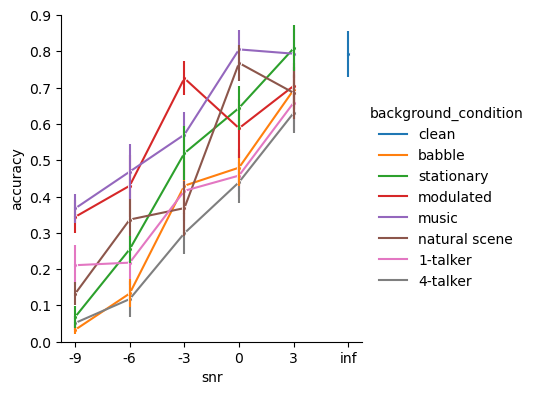

In [213]:
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot = part_summary_df[~part_summary_df.background_condition.isin(["catch_trial", 'audioset'])]

hue_order = ['clean', 'babble',  'stationary', 'modulated', 'music', 'natural scene', "1-talker", "4-talker"]

palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))

# Make color map 

# add markers to relplot
# plt.figure(figsize=(2,2))
g = sns.relplot(data=to_plot, x='snr', y='accuracy', hue='background_condition', hue_order=hue_order,
                # style='model', style_order=['human', "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"],
                  kind='line', marker='.', palette=palette, height=4, aspect=1)
# g.map(plt.errorbar, "snr", "accuracy", "std_error", marker=None, ls='none')


# iterate through each facet of the facetgrid
# for model, ax in g.axes_dict.items():
    # select the data for the facet
    # data = to_plot[to_plot['model'].eq(model)]

    # select the data for each hue group
for group, selected in to_plot.groupby('background_condition'):
    # plot the errorbar with the correct color for each group 
    # print(group)
    g.axes[0,0].errorbar(data=selected, x="snr", y="accuracy", yerr="std_error", color=palette[group], marker=None, ls='none' )

x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
plt.ylim(0,.9)

# plt.tight_layout()

babble
clean
modulated
music
natural scene
stationary


(0.0, 0.9)

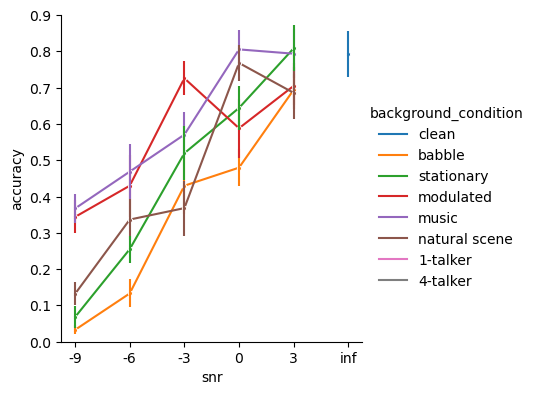

In [214]:
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot = part_summary_df[~part_summary_df.background_condition.isin(["catch_trial", "1-talker", "4-talker", "audioset"])]
# palette = dict(zip(to_plot.background_condition.unique(), sns.color_palette(n_colors= len(to_plot.background_condition.unique()), as_cmap=True)))

# add markers to relplot
# plt.figure(figsize=(2,2))
g = sns.relplot(data=to_plot, x='snr', y='accuracy', hue='background_condition', hue_order=hue_order,
                # style='model', style_order=['human', "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"],
                  kind='line', marker='.', palette=palette, height=4, aspect=1)
# g.map(plt.errorbar, "snr", "accuracy", "std_error", marker=None, ls='none')


# iterate through each facet of the facetgrid
# for model, ax in g.axes_dict.items():
    # select the data for the facet
    # data = to_plot[to_plot['model'].eq(model)]

    # select the data for each hue group
for group, selected in to_plot.groupby('background_condition'):
    # plot the errorbar with the correct color for each group 
    print(group)
    g.axes[0,0].errorbar(data=selected, x="snr", y="accuracy", yerr="std_error", color=palette[group], marker=None, ls='none' )

x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
plt.ylim(0,.9)



# plt.tight_layout()

In [113]:
# part_summary_df = part_summary_df[part_summary_df.jspsych_id != 'vgbrx2o3mb']

In [114]:
fontsize=14
n_participants = part_summary_df.id_subject.unique().shape[0]
fig, axs = plt.subplots(1, figsize=(8,8))

conds = part_summary_df.condition.unique()# order = ['clean', 'stationary_noise', 'natural_scene']
p = sns.boxplot( data=part_summary_df, x="condition",
                   y="mean",  #error='sem',
                   order=conds,
                  #capsize=0.1,
                   ax=axs)

sns.despine()
plt.ylim(0,1.05)
p.set_title(f"Word Speaker Noise word recognition participant performance \n (N={n_participants})",
                 fontsize=fontsize + 2)
p.set_xlabel("Condition",fontsize=fontsize)
p.set_ylabel("Prop. word correct", fontsize=fontsize)


p.set_xticklabels(labels=conds, rotation=90, size=10);



AttributeError: 'DataFrame' object has no attribute 'id_subject'

In [29]:
to_plot.snr.unique()

array([-9, -6, -3, 0, 3, 'inf'], dtype=object)

Text(63.61244791666667, 0.5, 'Prop. word correct')

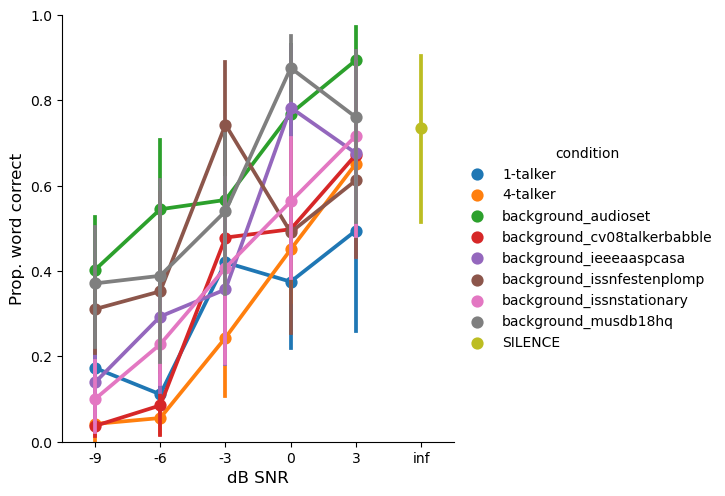

In [30]:
fontsize=14


n_participants = part_summary_df.id_subject.unique().shape[0]
# fig, axs = plt.subplots(1, figsize=(8,8))

to_plot = part_summary_df[part_summary_df.condition != 'catch_trial'].reset_index()
conds = to_plot.condition.unique()
p = sns.catplot( kind='point',data=to_plot, x="snr",
                   y="mean",  hue='condition', errorbar=('sem', 1), 
                #    linestyles="None",
                #    palette=["tab:blue", "tab:orange", "tab:green"],
                   )

sns.despine()
plt.ylim(0,1)
# axs.set_title(f"Word Speaker Noise word recognition participant performance \n (N={n_participants})",
#                  fontsize=fontsize + 2)
p.ax.set_xlabel("dB SNR",fontsize=12)
p.ax.set_ylabel("Prop. word correct", fontsize=12)

# p.set_xticklabels(labels=conds, rotation=0, size=fontsize)



Text(63.61244791666667, 0.5, 'Prop. word correct')

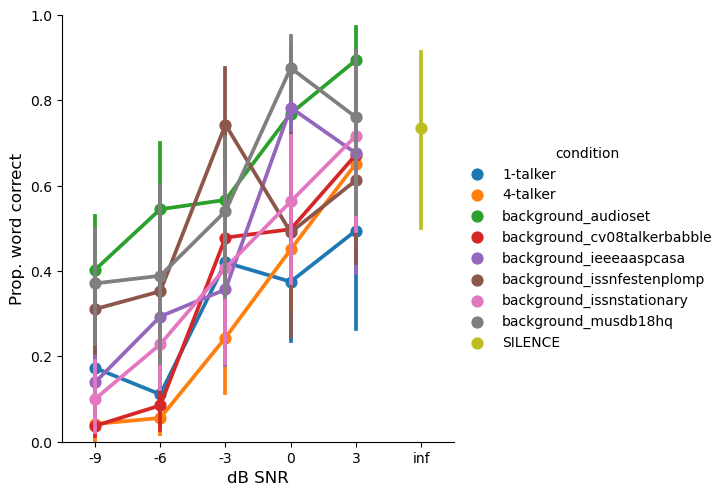

In [31]:
fontsize=14


n_participants = part_summary_df.id_subject.unique().shape[0]
# fig, axs = plt.subplots(1, figsize=(8,8))

to_plot = part_summary_df[part_summary_df.condition != 'catch_trial'].reset_index()
conds = to_plot.condition.unique()
p = sns.catplot( kind='point',data=to_plot, x="snr",
                   y="mean",  hue='condition', errorbar=('sem', 1), 
                #    linestyles="None",
                #    palette=["tab:blue", "tab:orange", "tab:green"],
                   )

sns.despine()
plt.ylim(0,1)
# axs.set_title(f"Word Speaker Noise word recognition participant performance \n (N={n_participants})",
#                  fontsize=fontsize + 2)
p.ax.set_xlabel("dB SNR",fontsize=12)
p.ax.set_ylabel("Prop. word correct", fontsize=12)

# p.set_xticklabels(labels=conds, rotation=0, size=fontsize)



In [32]:
to_plot.condition.value_counts()

background_issnstationary      45
1-talker                       44
background_ieeeaaspcasa        44
background_audioset            43
background_cv08talkerbabble    43
4-talker                       42
background_issnfestenplomp     42
background_musdb18hq           42
SILENCE                         8
Name: condition, dtype: int64